In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline

In [11]:
df=pd.read_csv("RealEstate_HousePrice_Dataset_4200 - RealEstate_HousePrice_Dataset_4200.csv.csv")

# Implement Polynomial Regression (Degrees 2–7)

C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid featu

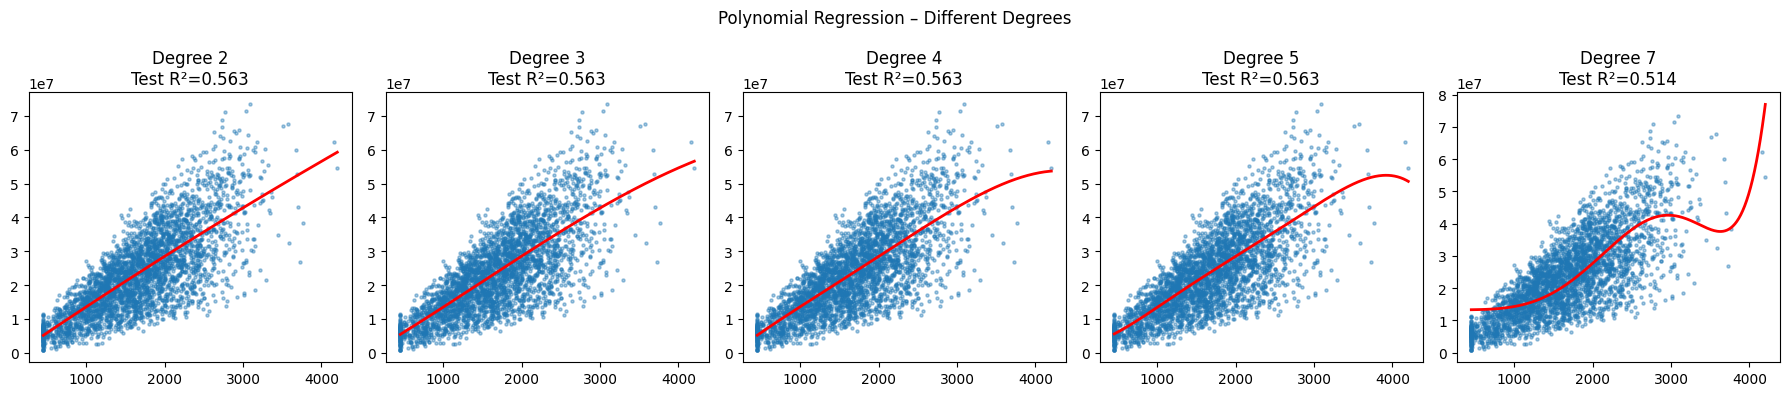

,Degree,Train R²,Test R²,RMSE
0,2,0.5725,0.5627,8183089.09
1,3,0.5726,0.5629,8181382.29
2,4,0.5727,0.5629,8181472.45
3,5,0.5727,0.5626,8183868.33
4,7,0.5261,0.5143,8624124.87


In [8]:
# Use ONE feature for polynomial regression
X = df[['area_sqft']]
y = df['house_price_inr']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

degrees = [2, 3, 4, 5, 7]
results = []

fig, axes = plt.subplots(1, len(degrees), figsize=(18, 4))

# Smooth plotting points
x_plot = np.linspace(
    X.min().values[0],
    X.max().values[0],
    300
).reshape(-1, 1)

for ax, d in zip(axes, degrees):

    # Pipeline
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=d)),
        ('lr', LinearRegression())
    ])

    # Train model
    pipe.fit(X_train, y_train)

    # Predictions
    y_pred = pipe.predict(X_test)

    # Scores
    train_r2 = pipe.score(X_train, y_train)

    test_r2 = r2_score(y_test, y_pred)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # Store results
    results.append({
        'Degree': d,
        'Train R²': round(train_r2, 4),
        'Test R²': round(test_r2, 4),
        'RMSE': round(rmse, 2)
    })

    # Scatter points
    ax.scatter(
        X_train,
        y_train,
        s=5,
        alpha=0.4
    )

    # Polynomial curve
    ax.plot(
        x_plot,
        pipe.predict(x_plot),
        color='red',
        linewidth=2
    )

    ax.set_title(f"Degree {d}\nTest R²={test_r2:.3f}")

# Overall title
plt.suptitle("Polynomial Regression – Different Degrees")

plt.tight_layout()
plt.show()

# Results table
pd.DataFrame(results)

# Compare Linear vs Polynomial Visually & Numerically

 Degree  Train R²  Test R²       RMSE
      1    0.5723   0.5625 8184696.70
      2    0.5725   0.5627 8183089.09
      3    0.5726   0.5629 8181382.29
      4    0.5727   0.5629 8181472.45
      5    0.5727   0.5626 8183868.33
      7    0.5261   0.5143 8624124.87


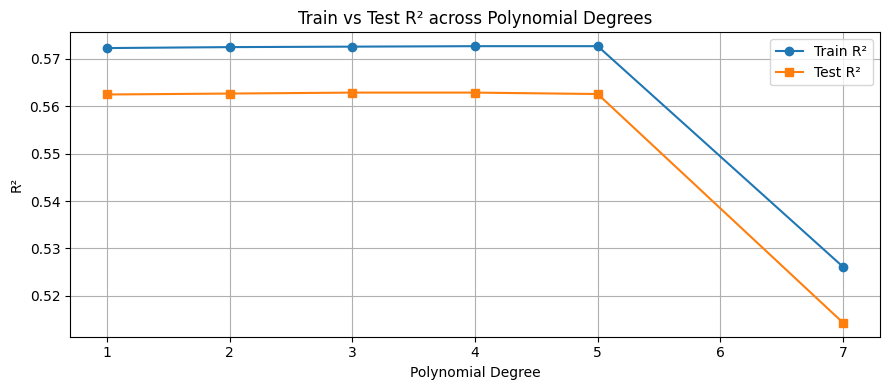

In [9]:
# Add degree-1 (linear) for comparison
all_degrees = [1] + degrees
comp = []
for d in all_degrees:
    pipe = Pipeline([('poly', PolynomialFeatures(degree=d)), ('lr', LinearRegression())])
    pipe.fit(X_train, y_train)
    comp.append({'Degree': d,
                 'Train R²': round(pipe.score(X_train, y_train),4),
                 'Test R²':  round(r2_score(y_test, pipe.predict(X_test)),4),
                 'RMSE':     round(np.sqrt(mean_squared_error(y_test, pipe.predict(X_test))),2)})

comp_df = pd.DataFrame(comp)
print(comp_df.to_string(index=False))

plt.figure(figsize=(9,4))
plt.plot(comp_df['Degree'], comp_df['Train R²'], marker='o', label='Train R²')
plt.plot(comp_df['Degree'], comp_df['Test R²'],  marker='s', label='Test R²')
plt.xlabel('Polynomial Degree'); plt.ylabel('R²')
plt.title('Train vs Test R² across Polynomial Degrees')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


# Identify Signs of Overfitting / Underfitting

From the plot above:
- **Degree 1 (Linear):** Low Train & Test R² → **Underfitting** – model cannot capture the quadratic pattern.
- **Degree 2–3:** High and similar Train & Test R² → **Good Fit** – captures the true curve.
- **Degree 5–7:** Very high Train R² but lower / dropping Test R² → **Overfitting** – model memorises noise.

**Takeaway:** Choose the degree where the gap between Train and Test R² is minimal and both are high.
